# **Lab 3: Image Enhancement in the Spatial Domain with Python**

## **Learning Objectives**
By the end of this practical, you should be able to:
* Explain the purpose of image enhancement and distinguish it from image restoration.
* Interpret image histograms and relate them to contrast and visual quality.
* Apply histogram equalisation and explain its effect on grey level distribution.
* Implement basic point processing transformations.
* Apply spatial filtering using neighbourhood operations.
* Compare smoothing and sharpening filters and explain their effects.
* Reason about edge effects and boundary handling in filtering.
* Combine multiple enhancement operations to achieve a desired outcome.

---

## **1. Introduction to Image Enhancement**
Image enhancement aims to improve the visual usefulness of an image by emphasising important features or suppressing unwanted effects such as noise.

**Typical goals include:**
* Improving contrast.
* Highlighting fine detail.
* Reducing noise.

This practical focuses on **spatial domain techniques**, where pixel values are manipulated directly.

---

## **2. Image Histograms and Contrast**
An image histogram describes the distribution of grey levels in an image and is a key tool for analysing contrast.

### **Exercise 2.1: Visualising an Image Histogram**
**Task:** Complete the code below to visualize the histogram of a randomly generated image.

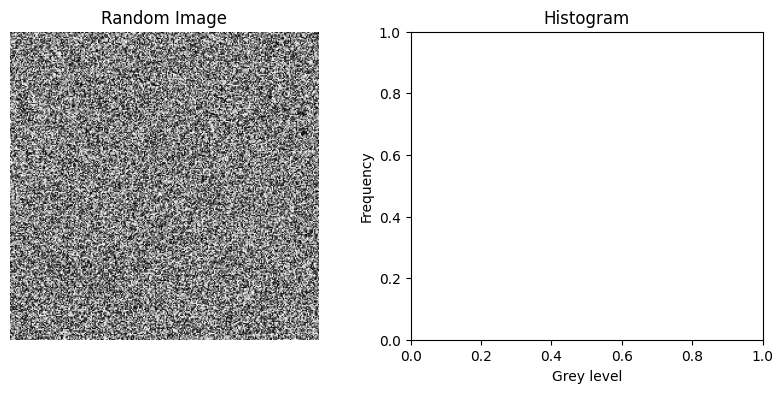

In [1]:
# apply to different image to see results better

import numpy as np
import matplotlib.pyplot as plt

# 1. Create a random image (256x256) with values between 0-255
# --- STUDENT TASK ---
# Fill in the parameters for np.randint()
image = np.random.randint(0,256, (256,256))

plt.figure(figsize=(10, 4))

# Display the image
plt.subplot(1, 2, 1)
plt.imshow(image, cmap='gray', vmin=0, vmax=255)
plt.title("Random Image")
plt.axis('off')

# 2. Plot the Histogram
plt.subplot(1, 2, 2)

# --- STUDENT TASK ---
# Fill in the parameters for plt.hist()
# Hint: You need to flatten the image, set bins to 256, and range to (0, 255)
# plt.hist(______________________________________________________________)

plt.title("Histogram")
plt.xlabel("Grey level")
plt.ylabel("Frequency")
plt.show()

# --- DISCUSSION QUESTIONS ---
#1.	Is the histogram evenly distributed or clustered in certain ranges?
#2.	What does this suggest about the contrast of the image?

## **3. Normalised Histograms**
Histograms are often normalised so they can be interpreted as probability distributions. A normalised histogram shows the probability of occurrence of each grey level.

### **Exercise 3.1: Computing a Normalised Histogram**
**Task:** Complete the code to calculate the normalised histogram. Remember that the sum of a normalised histogram must equal 1.

In [2]:
# Calculate the basic histogram first
hist, bins = np.histogram(image.flatten(), bins=256, range=(0,256))

# --- STUDENT TASK ---
# Calculate the normalised histogram
# Hint: Divide the histogram (hist) by the total number of pixels in the image
hist_norm = hist/image.shape[0]*image.shape[1]
print(hist_norm.sum())

# --- DISCUSSION QUESTIONS ---
# 1. Why does the normalised histogram sum to 1?
# 2. How can p(rₖ) be interpreted probabilistically? rk -> graylevel , p(rk) -> probability at this gray level

65536.0


## **4. Histogram Equalisation**
Histogram equalisation is a technique used to improve contrast by redistributing the intensity levels. It spreads out the most frequent intensity values, resulting in a more uniform distribution.

### **Exercise 4.1: Manual Histogram Equalisation**
**Task:** Fill in the missing steps to implement the equalisation process using the Cumulative Distribution Function (CDF).

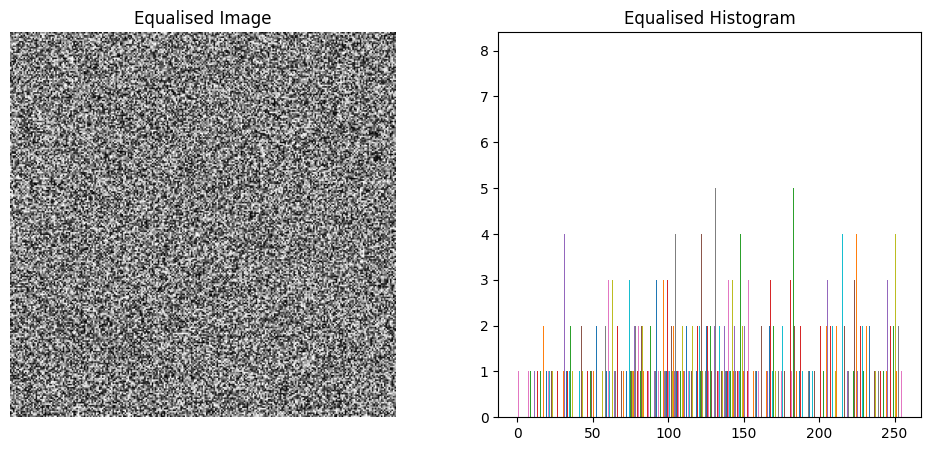

In [3]:
def hist_equalise(img):
    # Step 1: Calculate the histogram
    hist, _ = np.histogram(image.flatten(), bins=256, range=(0,256))

    # Step 2: Calculate the Cumulative Distribution Function (CDF)
    # --- STUDENT TASK ---
    # Hint: Use the numpy function that calculates the cumulative sum (cumsum)
    cdf = np.cumsum(hist)

    # Step 3: Normalise the CDF to be in the range [0, 255]
    # Formula: (cdf - min) * 255 / (max - min)
    cdf_norm = (cdf - cdf.min()) * 255 / (cdf.max() - cdf.min())
    cdf_norm = cdf_norm.astype(np.uint8)

    # Step 4: Map the original image pixels to the new values
    return cdf_norm[img]

# Applying the function to the original random image
equalised_image = hist_equalise(image)

# Visual comparison
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(equalised_image, cmap='gray', vmin=0, vmax=255)
plt.title("Equalised Image")
plt.axis('off')

plt.subplot(1, 2, 2)
# --- STUDENT TASK ---
# Plot the histogram of the equalised image to see the effect
plt.hist(equalised_image, bins=256, range=(0,255))
plt.title("Equalised Histogram")

plt.show()

# --- DISCUSSION QUESTIONS ---
# 1. How does the equalised histogram differ from the original one?
# 2. Does histogram equalisation always improve an image?

#**5. Local histogram equalisation (conceptual)**
Instead of applying histogram equalisation globally, it can be applied locally to small regions.

## **Exercise 5.1: Conceptual analysis**

**Without writing code:**

• Explain why local histogram equalisation can enhance local detail

• Explain why it may also amplify noise


## **6. Point processing operations**
Point processing modifies each pixel independently using a transformation function:
s = T(r)

### **Exercise 6.1: Creating a Negative Image**
**Task:** Complete the code to calculate the negative of the input image.

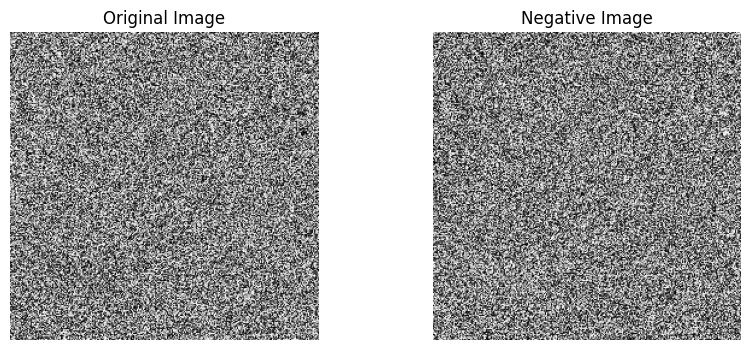

In [4]:
# --- STUDENT TASK ---
# Calculate the negative of the 'image' by subtracting each pixel from 255
negative_img = 255 - image # image.max - image

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.imshow(image, cmap='gray', vmin=0, vmax=255)
plt.title("Original Image")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(negative_img, cmap='gray', vmin=0, vmax=255)
plt.title("Negative Image")
plt.axis('off')

plt.show()

# --- DISCUSSION QUESTIONS ---
# 1. Why does this transformation highlight bright structures in dark regions?
# 2. In which types of images is this particularly useful?

## **7. Thresholding**
Thresholding is a simple way of segmenting an image into a binary foreground and background.

### **Exercise 7.1: Binary Thresholding**
**Task:** Turn all pixels above a specific 'threshold' to white (255) and all others to black (0).

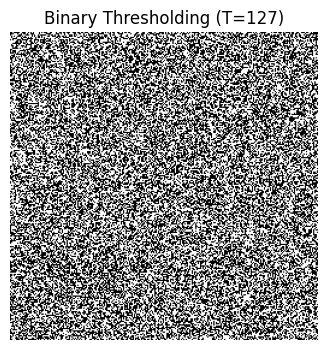

In [5]:
threshold = 127

# Create an image of zeros (black) with the same shape as the original
binary_img = np.zeros_like(image)

# --- STUDENT TASK ---
# Apply the threshold logic: set pixels to 255 where the original image > threshold_value
binary_img[image > threshold] = 255 # greater than threshold -> white

plt.figure(figsize=(6, 4))
plt.imshow(binary_img, cmap='gray')
plt.title(f"Binary Thresholding (T={threshold})")
plt.axis('off')
plt.show()

# --- DISCUSSION QUESTIONS ---
#1.	What information is lost through thresholding?
#2.	Why is threshold selection critical?

## **8. Log Transformation and Gamma Correction**

### **Exercise 8.1: Log Transformation**
The log transformation maps a narrow range of low grey-level values into a wider range of output levels.
**Formula:** $s = c \log(1 + r)$

### **Exercise 8.2: Gamma Correction (Power-Law)**
Gamma correction is used to correct the non-linear response of display devices.
**Formula:** $s = c \cdot r^\gamma$

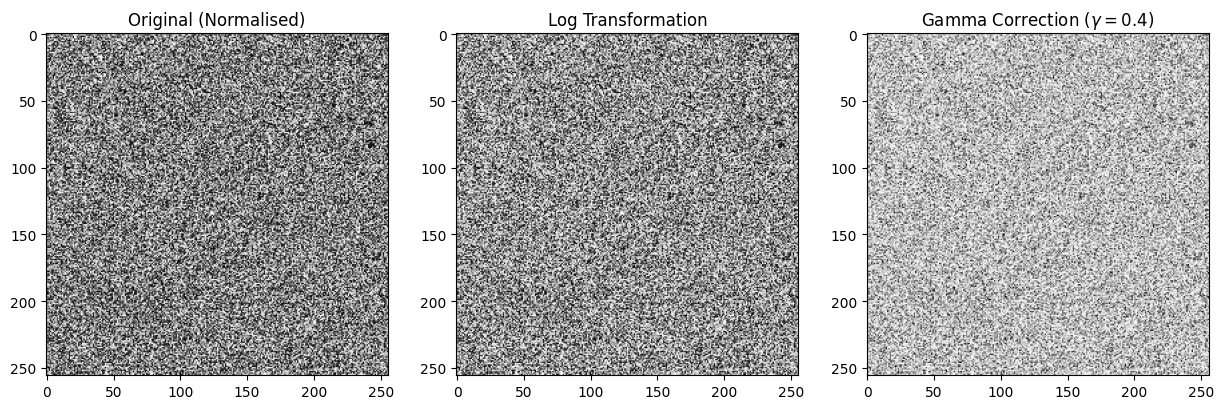

'night mode in camera'

In [6]:
# First, normalise the image to the range [0, 1] for these calculations
image_norm = image / 255.0

# --- Exercise 8.1: Log Transformation ---
# --- STUDENT TASK ---
# Implement the log transformation: log(1 + image_norm)
log_img = np.log(1 + image_norm)

# --- Exercise 8.2: Gamma Correction ---
# --- STUDENT TASK ---
# Implement gamma correction with gamma = 0.4 (Brightening)
gamma = 0.4
gamma_img = image_norm ** gamma

# Visualisation
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1); plt.imshow(image_norm, cmap='gray'); plt.title("Original (Normalised)")
plt.subplot(1, 3, 2); plt.imshow(log_img, cmap='gray'); plt.title("Log Transformation")
plt.subplot(1, 3, 3); plt.imshow(gamma_img, cmap='gray'); plt.title(f"Gamma Correction ($\gamma={gamma}$)")
plt.show()

# --- DISCUSSION QUESTIONS (From the Lab Sheet) ---
# 1. Which range of intensity values (dark or light) are expanded in a log transformation?
'''Dark'''
# 2. Why is the log transformation useful for images with a very large dynamic range (e.g., Fourier spectra)?
'''night mode in camera'''
# 3. How does decreasing gamma (e.g., to 0.4) affect the dark regions of an image?
# 4. Why is gamma correction important for display monitors?

## **9. Spatial Filtering: Smoothing**

### **Exercise 9.1: Mean (Averaging) Filter**
The Mean filter replaces each pixel value with the average of the pixels in its neighbourhood.

### **Exercise 9.2: Median Filter**
The Median filter replaces each pixel value with the median of the pixels in its neighbourhood.

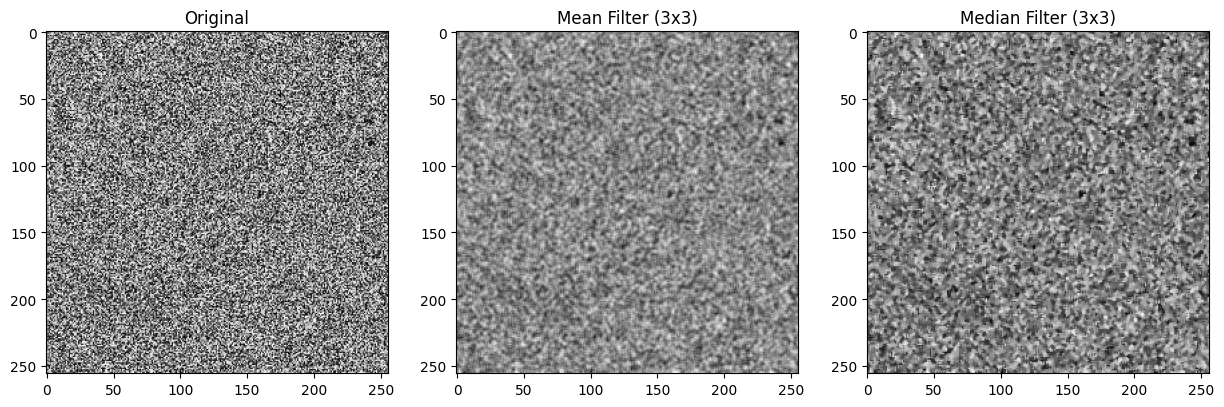

'Salt and Paper noise'

In [7]:
from scipy.ndimage import uniform_filter, median_filter

# --- Exercise 9.1: Mean Filter ---
# --- STUDENT TASK ---
# Apply a 3x3 mean filter using uniform_filter
mean_smoothed = uniform_filter(image, size=3)

# --- Exercise 9.2: Median Filter ---
# --- STUDENT TASK ---
# Apply a 3x3 median filter
median_smoothed = median_filter(image, size=3)

# Visualisation
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1); plt.imshow(image, cmap='gray'); plt.title("Original")
plt.subplot(1, 3, 2); plt.imshow(mean_smoothed, cmap='gray'); plt.title("Mean Filter (3x3)")
plt.subplot(1, 3, 3); plt.imshow(median_smoothed, cmap='gray'); plt.title("Median Filter (3x3)")
plt.show()

# --- DISCUSSION QUESTIONS  ---
# 1. (mean)What happens to noise and fine detail?
# 2. (mean)How does filter size affect the result?
# 3. (median)Why does the median filter preserve edges better?
# 4. (median)What type of noise is it especially good at removing?
'''Salt and Paper noise'''

## **10. Spatial Filtering: Sharpening**

### **Exercise 10.1: Laplacian Filter**
The Laplacian is a derivative operator that highlights regions of rapid intensity change. To sharpen an image, we subtract the Laplacian from the original image.

### **Exercise 10.2: Sobel Operator (Edge Detection)**
The Sobel operator calculates the image gradient, which is used to emphasize horizontal and vertical edges.

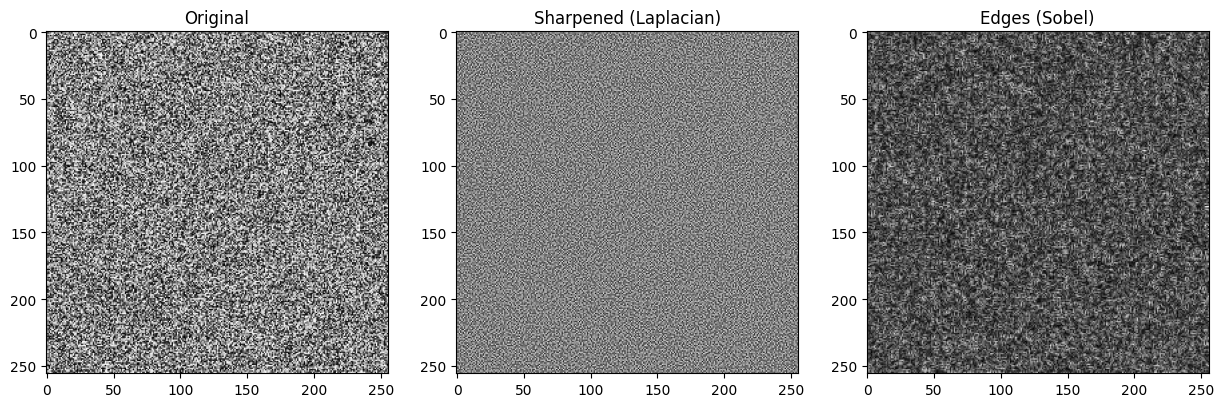

In [8]:
from scipy.ndimage import laplace, sobel

# --- Exercise 10.1: Laplacian Sharpening ---
# 1. Calculate the Laplacian
# --- STUDENT TASK ---
lap = laplace(image)

# 2. Subtract Laplacian from the original image to sharpen it
sharpened = lap - image 

# --- Exercise 10.2: Sobel Edge Detection ---
# --- STUDENT TASK ---
# 1. Calculate horizontal gradient (axis=0)
sx = sobel(image, axis=0)
# 2. Calculate vertical gradient (axis=1)
sy = sobel(image, axis=1)

# Calculate the magnitude of the edges
edges = np.hypot(sx, sy)

# Visualisation
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1); plt.imshow(image, cmap='gray'); plt.title("Original")
plt.subplot(1, 3, 2); plt.imshow(sharpened, cmap='gray'); plt.title("Sharpened (Laplacian)")
plt.subplot(1, 3, 3); plt.imshow(edges, cmap='gray'); plt.title("Edges (Sobel)")
plt.show()

# --- DISCUSSION QUESTIONS ---
# 1. Why does subtracting the Laplacian from the original image lead to sharpening?
# 2. What kind of structures are highlighted by the Laplacian?
# 3. What do the Sobel operators measure?
# 4. Why are horizontal and vertical filters combined in edge detection?

## **11. Edge Effects and Boundary Handling**
When filtering, the mask (kernel) overlaps the edge of the image. We must decide how to handle these boundary pixels.

### **Exercise 11.1: Comparing Boundary Modes**
**Task:** Observe how different 'modes' in `uniform_filter` affect the borders of the image.

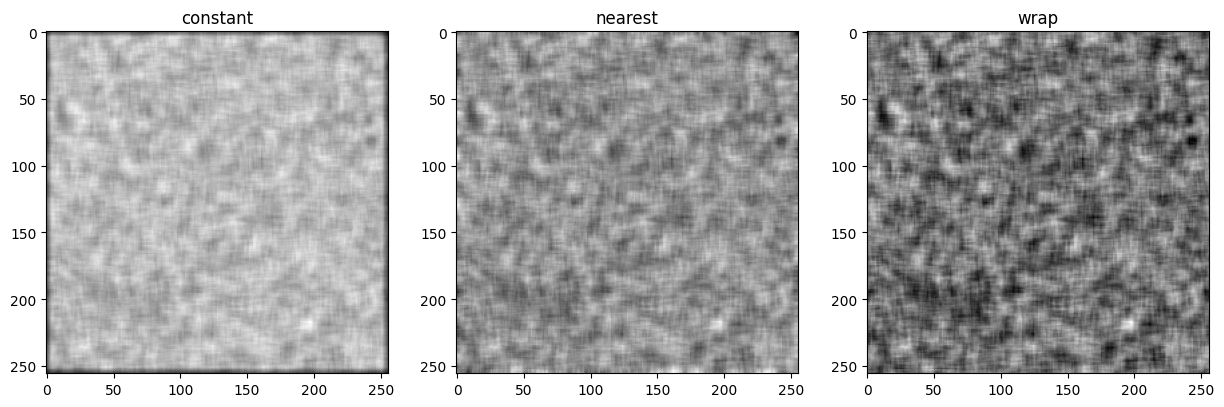

In [10]:
# --- STUDENT TASK ---
# Try different modes: 'constant' (zero padding), 'nearest', 'wrap'
smoothed_const = uniform_filter(image, size=9, mode='constant', cval=0)
smoothed_near  = uniform_filter(image, size=9, mode='nearest', cval=0)
smoothed_wrap  = uniform_filter(image, size=9, mode='wrap', cval=0)

plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1); plt.imshow(smoothed_const, cmap='gray'); plt.title("constant")
plt.subplot(1, 3, 2); plt.imshow(smoothed_near, cmap='gray'); plt.title("nearest")
plt.subplot(1, 3, 3); plt.imshow(smoothed_wrap, cmap='gray'); plt.title("wrap")
plt.show()

# --- DISCUSSION QUESTIONS ---
# 1. How does 'zero padding' affect the appearance of the image boundaries?
# 2. In what situations might 'wrap around' be a suitable boundary handling strategy?
# 3. Which strategy seems most 'natural' for general photographic images?

## 12. Mini Project: Combining Techniques
**Task:** Your goal is to produce the best possible version of the original image by combining the techniques you've learned.

1.	Start with a grey scale image
2.	Apply histogram equalisation
3.	Apply a smoothing filter
4.	Apply a sharpening filter
5.	Compare the original and final images

**Your explanation must reference:**
• Histogram processing

• Smoothing

• Sharpening

• The trade off between noise reduction and detail preservation


## **Reflection questions**
1.	Why does histogram equalisation sometimes over enhance images?
2.	Why is no single enhancement method sufficient in practice?
3.	How does human perception influence what we consider a “good” enhancement?
